In [ ]:
import pandas as pd
# Sprawdzamy nagłówki słowników
e_terra = pd.read_csv('enum_terra1.csv', encoding='unicode_escape', nrows=0)
e_wx = pd.read_csv('enum_wx1.csv', encoding='unicode_escape', nrows=0)

print("Kolumny w enum_terra1:", e_terra.columns.tolist())
print("Kolumny w enum_wx1:", e_wx.columns.tolist())

Kolumny w enum_terra1: ['value', 'description']
Kolumny w enum_wx1: ['value', 'description']


In [ ]:
import pandas as pd
import numpy as np

# 1. WCZYTANIE PLIKÓW - używamy dokładnie Twoich nazw kolumn
battles = pd.read_csv('battles.csv', encoding='unicode_escape')
belligerents = pd.read_csv('belligerents.csv', encoding='unicode_escape')
terrain = pd.read_csv('terrain.csv', encoding='unicode_escape')
weather = pd.read_csv('weather.csv', encoding='unicode_escape')
enum_terra = pd.read_csv('enum_terra1.csv', encoding='unicode_escape')
enum_wx = pd.read_csv('enum_wx1.csv', encoding='unicode_escape')

# 2. WYDOBYCIE LICZEBNOŚCI (str) Z belligerents.csv
# side A (atakujący) - attacker == 1
atk_df = belligerents[belligerents['attacker'] == 1][['isqno', 'str']].rename(columns={'str': 'str_a'})
# side B (obrońca) - attacker == 0
def_df = belligerents[belligerents['attacker'] == 0][['isqno', 'str']].rename(columns={'str': 'str_b'})

# 3. ŁĄCZENIE TABEL (Merge)
# Łączymy battles z siłami obu stron
df = pd.merge(battles[['isqno', 'name', 'wina', 'front', 'depth', 'time']], atk_df, on='isqno', how='inner')
df = pd.merge(df, def_df, on='isqno', how='inner')

# Dołączamy teren (terra1) i pogodę (wx1)
df = pd.merge(df, terrain[['isqno', 'terra1']], on='isqno', how='left')
df = pd.merge(df, weather[['isqno', 'wx1']], on='isqno', how='left')

# 4. MAPOWANIE OPISÓW (Słowniki)
df['terrain_desc'] = df['terra1'].map(dict(zip(enum_terra['value'], enum_terra['description'])))
df['weather_desc'] = df['wx1'].map(dict(zip(enum_wx['value'], enum_wx['description'])))

# 5. CZYSZCZENIE DANYCH LICZBOWYCH
# Kolumna 'str' ma przecinki i znaki zapytania w Twoim pliku
for col in ['str_a', 'str_b', 'front', 'depth', 'time']:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Obliczamy Force Ratio (Stosunek sił)
df['force_ratio'] = df['str_a'] / df['str_b']

# Usuwamy wiersze, gdzie brakuje kluczowych danych dla modelu
df_final = df.dropna(subset=['wina', 'str_a', 'str_b', 'terrain_desc', 'weather_desc']).copy()

# 6. WYŚWIETLENIE REZULTATU
print(f"ETAP 1 ZAKOŃCZONY. Mamy {len(df_final)} bitew gotowych do modelu.")
print("Nagłówki Twojej nowej tabeli:")
display(df_final[['name', 'str_a', 'str_b', 'force_ratio', 'terrain_desc', 'weather_desc', 'front', 'wina']].head(10))

ETAP 1 ZAKOŃCZONY. Mamy 635 bitew gotowych do modelu.
Nagłówki Twojej nowej tabeli:


,name,str_a,str_b,force_ratio,terrain_desc,weather_desc,front,wina
1,WHITE MOUNTAIN,40000.0,21000.0,1.904762,Rolling,Dry,1.0,1.0
2,WIMPFEN,20000.0,20000.0,1.000000,Rolling,Dry,0.0,1.0
4,LUTTER,17000.0,20000.0,0.850000,Rolling,Dry,0.0,1.0
6,THE LECH,33000.0,27000.0,1.222222,Rolling,Dry,0.0,1.0
8,LUETZEN,18996.0,21770.0,0.872577,Rolling,Dry,0.0,1.0
10,WITTSTOCK,22000.0,30000.0,0.733333,Rolling,Dry,0.0,1.0
11,BREITENFELD II,25000.0,30000.0,0.833333,Rolling,Dry,0.0,1.0
12,ROCROI,23000.0,26000.0,0.884615,Rolling,Dry,0.0,1.0
13,TUTTLINGEN,22000.0,18000.0,1.222222,Rolling,Dry,0.0,1.0
14,FREIBURG,19000.0,16000.0,1.187500,Rugged,Dry,0.0,1.0


In [ ]:
import pandas as pd

# Tworzymy zestaw 3 fikcyjnych bitew
# Musimy zachować identyczne kolumny jak w X_train
fake_battles = pd.DataFrame(columns=X_train.columns)

# Bitwa 1: Absurdalna (1 żołnierz vs 1 000 000)
# Czy model nadal powie, że strona A wygra?
fake_battles.loc[0] = 0 # reset
fake_battles.loc[0, 'str_a'] = 1
fake_battles.loc[0, 'str_b'] = 1000000
fake_battles.loc[0, 'force_ratio'] = 0.000001
fake_battles.loc[0, 'front'] = 0.1
fake_battles.loc[0, 'terrain_desc_Rugged'] = 1 # Bardzo trudny teren
fake_battles.loc[0, 'weather_desc_Wet'] = 1    # Fatalna pogoda

# Bitwa 2: Równowaga (10k vs 10k) w idealnych warunkach
fake_battles.loc[1] = 0
fake_battles.loc[1, 'str_a'] = 10000
fake_battles.loc[1, 'str_b'] = 10000
fake_battles.loc[1, 'force_ratio'] = 1.0
fake_battles.loc[1, 'front'] = 5.0
fake_battles.loc[1, 'terrain_desc_Flat'] = 1   # Płasko
fake_battles.loc[1, 'weather_desc_Dry'] = 1    # Sucho

# Bitwa 3: Przewaga A (20k vs 10k), ale fatalny teren
fake_battles.loc[2] = 0
fake_battles.loc[2, 'str_a'] = 20000
fake_battles.loc[2, 'str_b'] = 10000
fake_battles.loc[2, 'force_ratio'] = 2.0
fake_battles.loc[2, 'front'] = 2.0
fake_battles.loc[2, 'terrain_desc_Rugged'] = 1 # Góry
fake_battles.loc[2, 'weather_desc_Wet'] = 1    # Deszcz

# Uzupelniamy resztę kolumn zerami (te, których nie użyliśmy)
fake_battles = fake_battles.fillna(0)

# PRZEWIDYWANIE
predictions = model_smart.predict(fake_battles)
probabilities = model_smart.predict_proba(fake_battles)

print("--- WYNIKI TESTU ZDERZENIOWEGO ---")
for i, pred in enumerate(predictions):
    wynik = "WYGRANA A" if pred == 1 else "PRZEGRANA A"
    pewnosc = probabilities[i][int(pred)] * 100
    print(f"Bitwa {i+1}: Model przewiduje {wynik} (Pewność: {pewnosc:.2f}%)")

--- WYNIKI TESTU ZDERZENIOWEGO ---
Bitwa 1: Model przewiduje WYGRANA A (Pewność: 100.00%)
Bitwa 2: Model przewiduje WYGRANA A (Pewność: 100.00%)
Bitwa 3: Model przewiduje PRZEGRANA A (Pewność: 66.01%)


/tmp/ipython-input-2243131369.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fake_battles.loc[0, 'force_ratio'] = 0.000001
/tmp/ipython-input-2243131369.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fake_battles.loc[0, 'front'] = 0.1


--- ANALIZA MODELU (ZBALANSOWANE WAGI KLAS) ---
Skuteczność ogólna (Accuracy): 0.54


,precision,recall,f1-score,support
0.0,0.16,0.67,0.26,15.00
1.0,0.92,0.53,0.67,112.00
accuracy,0.54,0.54,0.54,0.54
macro avg,0.54,0.60,0.46,127.00
weighted avg,0.83,0.54,0.62,127.00


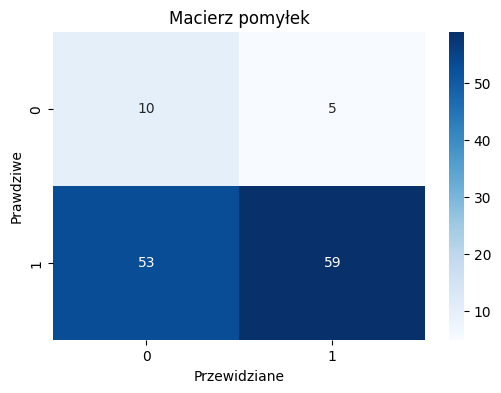

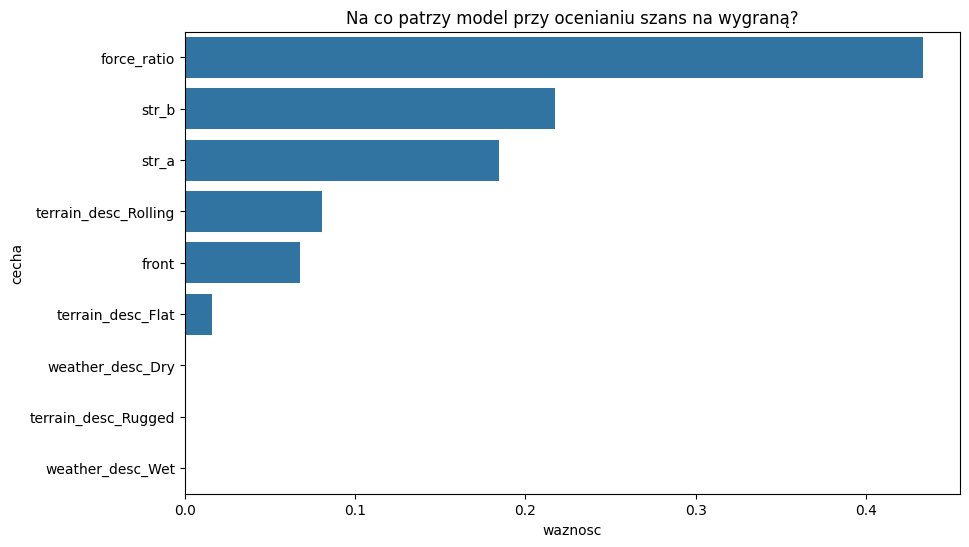

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. PRZYGOTOWANIE CECH I CELU
# Wybieramy cechy i robimy One-Hot Encoding dla terenu i pogody
df_ml = pd.get_dummies(df_final[['str_a', 'str_b', 'force_ratio', 'front', 'terrain_desc', 'weather_desc']],
                       columns=['terrain_desc', 'weather_desc'])

X = df_ml
y = df_final['wina']

# 2. PODZIAŁ DANYCH (80% trening, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. TRENOWANIE "MĄDRZEJSZEGO" MODELU
# Używamy class_weight='balanced', żeby model widział porażki
model_smart = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
model_smart.fit(X_train, y_train)

# 4. WYNIKI I METRYKI
y_pred_smart = model_smart.predict(X_test)

print(f"--- ANALIZA MODELU (ZBALANSOWANE WAGI KLAS) ---")
print(f"Skuteczność ogólna (Accuracy): {accuracy_score(y_test, y_pred_smart):.2f}")

# Tabela metryk
report = classification_report(y_test, y_pred_smart, output_dict=True)
df_report = pd.DataFrame(report).transpose()
display(df_report.style.background_gradient(cmap='Blues').format("{:.2f}"))

# 5. MACIERZ POMYŁEK
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_smart), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek")
plt.xlabel("Przewidziane")
plt.ylabel("Prawdziwe")
plt.show()

# 6. WAŻNOŚĆ CECH
importances = pd.DataFrame({'cecha': X.columns, 'waznosc': model_smart.feature_importances_})
importances = importances.sort_values(by='waznosc', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='waznosc', y='cecha')
plt.title("Na co patrzy model przy ocenianiu szans na wygraną?")
plt.show()

Link do dysku:
https://drive.google.com/drive/folders/14jGzNSGhDNDBi5Nw42wNJYLazO3oMCuX?usp=drive_link

Link do datasetu: https://www.kaggle.com/datasets/residentmario/database-of-battles



### **1. Geneza – Początki i Porzucenie**
Na samym początku, kiedy zacząłem ten projekt, odszukałem na Kaggle bazę danych o zabójstwach w USA: `"Dataset Homicide Reports, 1980-2014"`. Zastanawiałem się, czy taki model mógłby przewidywać, czy konkretna sprawa została rozwiązana i na podstawie czego to wydedukował. Wybrałem więc kluczowe cechy (rodzaj broni, powiązania ze sprawcą czy płeć) i przystąpiłem do budowania modelu. Jednak po ukończeniu go stwierdziłem, że nie jestem z niego zadowolony – był po prostu nudny, miał mało cech, a analiza nie była zbyt ciekawa. Postanowiłem porzucić ten pierwotny pomysł.

### **2. Olśnienie**
Od początku chciałem jakoś uwikłać w ten projekt historię, żeby przyjemnie się go robiło. Nie byłem pewien, czy historia w ogóle łączy się z ML, więc oczywiście spytałem Gemini. Odpowiedział, że **„OCZYWIŚCIE TAK, PEWNIE”**, i że historia to jest w ogóle najlepsza w ML. Nigdy nie byłem tak pewny żadnej informacji jak tej otrzymanej w tamtym momencie. ;)

### **3. Początki**
Wybrałem dataset **"Historical Military Battles"**. Główną częścią zbioru były bitwy I WŚ, ale znalazły się tam też starcia z Wojny Trzydziestoletniej czy Wojen Napoleońskich.

**Kluczowy prompt, który rozpoczął proces**
> *„Wybrałem ten dataset 'Historical Military Battles', ale plików jest bardzo dużo, a kolumn jeszcze więcej. Na początek stwórz kod, który połączy to wszystko w jedną spójną tabelę, potem wybierz kilka najważniejszych cech jak liczebność stron, teren, pogoda, która strona wygrała”.*

Kolejnymi promptami czyściłem dataset z pustych pól i "śmieci". Temu procesowi towarzyszył szereg błędów `KeyError`, ostatecznie, stworzyłem własną cechę – `force_ratio`, która najlepiej obrazuje układ sił na polu bitwy.

### **4. Proces**
Do budowy modelu klasyfikacyjnego użyłem **Drzewa Decyzyjnego**. Moim celem było przewidzenie kolumny `wina` (wygrana strony a). Podzieliłem dane na zbiór treningowy i testowy (`train_test_split`), aby uniknąć przeuczenia.

Pierwszy model osiągnął **Accuracy 88%**. Jednak po stworzeniu **macierzy pomyłek** i analizie wykresu, zauważyłem, że wpadłem w klasyczną pułapkę. Model, ze względu na to, że w danych zdecydowaną większość bitew wygrywała strona atakująca, zaczął automatycznie wszystko uznawać za zwycięstwo strony "a".  
**Model bezużyteczny**.

Chciałem go poprawić. Z prezentacji na platformie pamiętałem „coś” o tym, że jak jedne wartości w danych są wielkie, a drugie małe, to model automatycznie pomija te małe, więc trzeba go karać i sztucznie zwiększać wagę "porażki". Porozmawiałem z czatem i tak doszliśmy do parametru **`class_weight='balanced'`**. To zmusiło model do „uważniejszego” patrzenia na rzadszą klasę porażek.

W efekcie `recall` dla porażek (klasy 0.0) skoczył z 0 do **0.53** (a `F1-score` dla klasy 0.0 z 0 do 0.36), co było ogromnym postępem. Na wykresie **Ważności Cech (`Feature Importance`)** zobaczyłem, że model zaczął patrzeć na inne wartości niż tylko siła strony atakującej (`str_a`), takie jak `terrain_desc_Rolling` czy `front`.

### **5. Test Zderzeniowy**
Przygotowałem 3 abstrakcyjne scenariusze z danymi syntetycznymi w celu sprawdzenia, jak model sobie poradzi.

*   **Bitwa 1 (Absurd):** 1 atakujący vs 1 000 000 obrońców (Góry, Deszcz).  
   **Wynik:** Model przewidział **WYGRANĄ A (100% pewności)**. To był absolutny absurd logiczny.
*   **Bitwa 2 (Równowaga):** 10k vs 10k (Płasko, Sucho).  
**Wynik:** Model przewidział WYGRANĄ A (100% pewności).
*   **Bitwa 3 (Taktyka):** 20k vs 10k (Góry, Deszcz).  
**Wynik:** Model przewidział **PRZEGRANĄ A (66.01% pewności)**.

### **6. Wnioski**
**Model zdecydowanie udało mi się oszukać.** Pomimo zastosowania wag klas i polepszenia metryki `recall`, model wciąż ogromnie faworyzuje atakującego (bias atakującego?). W bitwie 3 model pozytywnie mnie zaskoczył, ponieważ mimo podwójnej przewagi strony A, przewidział jej przegraną, co było zgodne z intuicją ze względu na złe warunki i teren. To dowodzi, że balansowanie klas faktycznie zmusiło model do głębszej analizy.

Dowodzi to, że żeby stworzyć lepszy model, potrzebowałbym większej liczby porażek w danych, żeby model miał się gdzie nauczyć o „słabych atakach”. Widzę też, że **„bias atakującego”** w pewnym ujęciu ma sens, ponieważ w realnym świecie, kiedy strona atakująca decyduje się na atak, to zwykle jest przekonana o możliwości zwycięstwa, więc również występuje taki „realny bias danych”.

**Czy zaufałbym temu modelowi w biznesie?**
Absolutnie pod żadnym pozorem nie, jednak w naukowym i rozrywkowym celu, zamierzam go ulepszać – może kiedyś coś z niego będzie.